In [12]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

## Simple Chatbot

A StateGraph object defines the structure of our chatbot as a "state machine". We'll add nodes to represent the llm and functions our chatbot can call and edges to specify how the bot should transition between these functions.

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

Our graph can now handle two key tasks:

Each node can receive the current State as input and output an update to the state.
Updates to messages will be appended to the existing list rather than overwriting it, thanks to the prebuilt add_messages function used with the Annotated syntax.

In [3]:
llm = ChatOpenAI(model="gpt-4")

In [4]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

Nodes represent units of work. They are typically regular python functions.

In [5]:
graph_builder.add_node("chatbot", chatbot)

Notice how the chatbot node function takes the current State as input and returns a dictionary containing an updated messages list under the key "messages". This is the basic pattern for all LangGraph node functions.
The add_messages function in our State will append the llm's response messages to whatever messages are already in the state.

Next, add an entry point. This tells our graph where to start its work each time we run it.

In [6]:
graph_builder.add_edge(START, "chatbot")

Similarly, set a finish point. This instructs the graph "any time this node is run, you can exit."

In [7]:
graph_builder.add_edge("chatbot", END)

Finally, we'll want to be able to run our graph. To do so, call "compile()" on the graph builder. This creates a "CompiledGraph" we can use invoke on our state.

In [8]:
graph = graph_builder.compile()

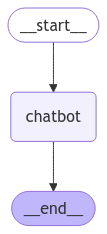

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [10]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User:  quit


Goodbye!


## Tools

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")

[{'url': 'https://medium.com/@kbdhunga/beginners-guide-to-langgraph-understanding-state-nodes-and-edges-part-1-897e6114fa48',
  'content': "Beginner’s Guide to LangGraph: Understanding State, Nodes, and Edges — Part 1 | by Kamal Dhungana | Medium Beginner’s Guide to LangGraph: Understanding State, Nodes, and Edges — Part 1 LangGraph — State, Node and Edge Explained Mainly, we will focus on various components of LangGraph: State, Node, and Edges, and how to build a complete graph from these components. Once we understand these components, we will be able to build relatively complex LangGraph-based agents. Each node represents a specific function or operation that processes the current state. Nodes can perform computations, modify the state, or generate outputs based on the input they receive. Follow 1.2K Followers Data scientist with a passion for AI, Regularly blogging about LLM and OpenAI's innovations,Sharing insights for AI community growth Follow"},
 {'url': 'https://blog.langchain

The results are page summaries our chat bot can use to answer questions.

In [12]:
graph_builder = StateGraph(State)

In [13]:
llm = ChatOpenAI(model="gpt-4")

In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [16]:
graph_builder.add_node("chatbot", chatbot)

Next we need to create a function to actually run the tools if they are called. We'll do this by adding the tools to a new node.

Below, we implement a BasicToolNode that checks the most recent message in the state and calls tools if the message contains tool_calls. It relies on the LLM's tool_calling support, which is available in Anthropic, OpenAI, Google Gemini, and a number of other LLM providers.

We will later replace this with LangGraph's prebuilt ToolNode to speed things up, but building it ourselves first is instructive.

In [18]:
import json

from langchain_core.messages import ToolMessage


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)


With the tool node added, we can define the conditional_edges.

Recall that edges route the control flow from one node to the next. Conditional edges usually contain "if" statements to route to different nodes depending on the current graph state. These functions receive the current graph state and return a string or list of strings indicating which node(s) to call next.

Below, call define a router function called route_tools, that checks for tool_calls in the chatbot's output. Provide this function to the graph by calling add_conditional_edges, which tells the graph that whenever the chatbot node completes to check this function to see where to go next.

The condition will route to tools if tool calls are present and END if not.

In [19]:
def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [20]:
# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "END" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", END: END},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

Like the prebuilt tools_condition, our function returns the END string if no tool calls are made. When the graph transitions to END, it has no more tasks to complete and ceases execution. Because the condition can return END, we don't need to explicitly set a finish_point this time. Our graph already has a way to finish!

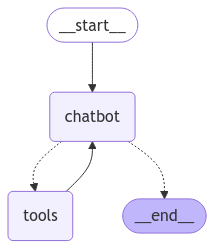

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now we can ask the bot questions outside its training data.

In [22]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User:  Qual foi o resultado do último jogo do flamengo? 


Assistant: 
Assistant: [{"url": "https://www.placardefutebol.com.br/time/flamengo/ultimos-jogos", "content": "\u00daltimos jogos do Flamengo. Notifica\u00e7\u00f5es. Campeonato Carioca. Fluminense. Flamengo. 0 - 0. S\u00c1B, 08/02 \u00b7 Campeonato Carioca. Portuguesa-RJ. Flamengo."}, {"url": "https://pt.besoccer.com/time/jogos/flamengo-rio-janeiro", "content": "Partidas Flamengo ; Flamengo. Flamengo. 2-0. Fluminense ; Vasco da Gama. Vasco da Gama. 1-4. Flamengo ; Flamengo. Flamengo. 2-1. Racing Club."}]
Assistant: O último jogo do Flamengo foi contra o Fluminense e o resultado foi um empate de 0 a 0. Esta informação foi obtida a partir do site [placardefutebol.com.br](https://www.placardefutebol.com.br/time/flamengo/ultimos-jogos).


User:  quit


Goodbye!


## Replacing BasicToolNode for the ToolNode and route_tools with the tools_condition

In [23]:
from langgraph.prebuilt import ToolNode, tools_condition

In [24]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [25]:
graph_builder = StateGraph(State)

In [26]:
llm = ChatOpenAI(model="gpt-4")

In [27]:
tool = TavilySearchResults(max_results=2)
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

In [28]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [29]:
graph_builder.add_node("chatbot", chatbot)

In [30]:
tool_node = ToolNode(tools=[tool])

In [31]:
graph_builder.add_node("tools", tool_node)

In [32]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile()

## Adding Memory to the Chatbot

Our chatbot can now use tools to answer user questions, but it doesn't remember the context of previous interactions. This limits its ability to have coherent, multi-turn conversations

LangGraph solves this problem through persistent checkpointing. If you provide a checkpointer when compiling the graph and a thread_id when calling your graph, LangGraph automatically saves the state after each step. When you invoke the graph again using the same thread_id, the graph loads its saved state, allowing the chatbot to pick up where it left off.

In [33]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [34]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [35]:
tool = TavilySearchResults(max_results=2)
tools = [tool]
llm = ChatOpenAI(model="gpt-4")
llm_with_tools = llm.bind_tools(tools)

In [37]:
graph_builder = StateGraph(State)

In [38]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [39]:
graph = graph_builder.compile(checkpointer=memory)

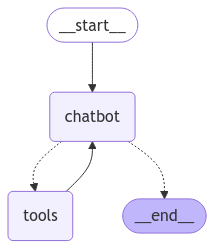

In [40]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now you can interact with your bot! First, pick a thread to use as the key for this conversation.

In [41]:
config = {"configurable": {"thread_id": "1"}}

In [42]:
user_input = "Olá! Meu nome é José"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Olá! Meu nome é José
================================== Ai Message ==================================

Olá, José! Como posso te ajudar hoje?


The config was provided as the second positional argument when calling our graph. It importantly is not nested within the graph inputs ({'messages': []}).

In [43]:
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Of course, José! I'm here to assist you. Please tell me how can I help you today?


In [44]:
# The only difference is we change the `thread_id` here to "2" instead of "1"
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

As an AI developed by OpenAI, I don't have the ability to remember or store personal data from users unless explicitly given in the course of the conversation. I am designed to respect user privacy and confidentiality.


To inspect a graph's state for a given config at any time, call get_state(config).

In [45]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Olá! Meu nome é José', additional_kwargs={}, response_metadata={}, id='73bee86c-26ba-4659-8d3c-279493e5d3a2'), AIMessage(content='Olá, José! Como posso te ajudar hoje?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 89, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-18217309-abef-496a-ad54-2a8ae3309a12-0', usage_metadata={'input_tokens': 89, 'output_tokens': 15, 'total_tokens': 104, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content='Remember my name?', additional_kwargs={}, response_metadata={}, id='0

In [46]:
snapshot.next

()

## Part 4: Human-in-the-loop

LangGraph's persistence layer supports human-in-the-loop workflows, allowing execution to pause and resume based on user feedback. The primary interface to this functionality is the interrupt function. Calling interrupt inside a node will pause execution. Execution can be resumed, together with new input from a human, by passing in a Command. interrupt is ergonomically similar to Python's built-in input(), with some caveats. We demonstrate an example below.

We will make one change, which is to add a simple human_assistance tool accessible to the chatbot. This tool uses interrupt to receive information from a human.

In [54]:
from langgraph.types import Command, interrupt
from langchain_core.tools import tool

In [51]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [52]:
graph_builder = StateGraph(State)

In [55]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

In [56]:
tool = TavilySearchResults(max_results=2)
tools = [tool, human_assistance]
llm = ChatOpenAI(model="gpt-4")
llm_with_tools = llm.bind_tools(tools)

In [57]:
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}

In [58]:
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [59]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

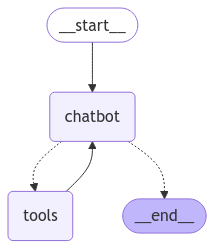

In [60]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [61]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_fYUdnbNIPIh5WomLPXRBcarr)
 Call ID: call_fYUdnbNIPIh5WomLPXRBcarr
  Args:
    query: Expert guidance for building an AI agent


The chatbot generated a tool call, but then execution has been interrupted! Note that if we inspect the graph state, we see that it stopped at the tools node:

In [62]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

Similar to Python's built-in input() function, calling interrupt inside the tool will pause execution. Progress is persisted based on our choice of checkpointer-- so if we are persisting with Postgres, we can resume at any time as long as the database is alive. Here we are persisting with the in-memory checkpointer, so we can resume any time as long as our Python kernel is running.

To resume execution, we pass a Command object containing data expected by the tool. The format of this data can be customized based on our needs. Here, we just need a dict with a key "data":

In [63]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_fYUdnbNIPIh5WomLPXRBcarr)
 Call ID: call_fYUdnbNIPIh5WomLPXRBcarr
  Args:
    query: Expert guidance for building an AI agent
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Sure, I've received the advice from our expert. It is advised to utilize LangGraph for building your agent as it is considered more reliable and extensible than simple autonomous agents. I hope this helps! Please let me know if there is anything more you need.


Since we have already added a checkpointer, as long as the underlying persistence layer is running, the graph can be paused indefinitely and resumed at any time as if nothing had happened.

## Part 5: Customizing State

In [99]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]
    name: str
    birthday: str

Adding this information to the state makes it easily accessible by other graph nodes (e.g., a downstream node that stores or processes the information), as well as the graph's persistence layer.

Here, we will populate the state keys inside of our human_assistance tool. This allows a human to review the information before it is stored in the state. We will again use Command, this time to issue a state update from inside our tool

In [100]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool

from langgraph.types import Command, interrupt

In [101]:
@tool
# Note that because we are generating a ToolMessage for a state update, we
# generally require the ID of the corresponding tool call. We can use
# LangChain's InjectedToolCallId to signal that this argument should not
# be revealed to the model in the tool's schema.
def human_assistance(
    name: str, birthday: str, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request assistance from a human."""
    human_response = interrupt(
        {
            "question": "Is this correct?",
            "name": name,
            "birthday": birthday,
        },
    )
    # If the information is correct, update the state as-is.
    if human_response.get("correct", "").lower().startswith("y"):
        verified_name = name
        verified_birthday = birthday
        response = "Correct"
    # Otherwise, receive information from the human reviewer.
    else:
        verified_name = human_response.get("name", name)
        verified_birthday = human_response.get("birthday", birthday)
        response = f"Made a correction: {human_response}"

    # This time we explicitly update the state with a ToolMessage inside
    # the tool.
    state_update = {
        "name": verified_name,
        "birthday": verified_birthday,
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)],
    }
    # We return a Command object in the tool to update our state.
    return Command(update=state_update)

In [102]:
tavily = TavilySearchResults(max_results=2)
tools = [tavily, human_assistance]
llm = ChatOpenAI(model="gpt-4")
llm_with_tools = llm.bind_tools(tools)

In [103]:
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}


graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

In [104]:
user_input = (
    "Can you look up when LangGraph was released? "
    "When you have the answer, use the human_assistance tool for review."
)
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Can you look up when LangGraph was released? When you have the answer, use the human_assistance tool for review.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_RvR712IimiElQMcfwcTveGa8)
 Call ID: call_RvR712IimiElQMcfwcTveGa8
  Args:
    query: LangGraph release date
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://pypi.org/project/langgraph/", "content": "LangGraph is a library for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows. The simplest way to create a tool-calling agent in LangGraph is to use create_react_agent: # Define the tools for the agent to use # Define the tools for the agent to use # This means that after `tools` is called, `agent` node is called next. workflow.add_edge(\"t

In [105]:
human_command = Command(
    resume={
        "name": "LangGraph",
        "birthday": "Jan 17, 2024",
    },
)

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_sPxyapMulN6tSpvhI4iX7n22)
 Call ID: call_sPxyapMulN6tSpvhI4iX7n22
  Args:
    name: Assistant
    birthday: Feb 6, 2025
================================= Tool Message =================================
Name: human_assistance

Made a correction: {'name': 'LangGraph', 'birthday': 'Jan 17, 2024'}
================================== Ai Message ==================================

LangGraph was released on January 17, 2024.


Note that these fields are now reflected in the state:

In [106]:
snapshot = graph.get_state(config)

In [108]:
snapshot = graph.get_state(config)

{k: v for k, v in snapshot.values.items() if k in ("name", "birthday")}

{'name': 'LangGraph', 'birthday': 'Jan 17, 2024'}

LangGraph gives a high degree of control over the application state. For instance, at any point (including when interrupted), we can manually override a key using

In [109]:
graph.update_state(config, {"name": "LangGraph (library)"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efe875a-2302-6ef8-8006-ffead4a8103d'}}

In [110]:
snapshot = graph.get_state(config)

{k: v for k, v in snapshot.values.items() if k in ("name", "birthday")}

{'name': 'LangGraph (library)', 'birthday': 'Jan 17, 2024'}

## Part 6: Time Travel

But what if you want to let your user start from a previous response and "branch off" to explore a separate outcome? Or what if you want users to be able to "rewind" your assistant's work to fix some mistakes or try a different strategy (common in applications like autonomous software engineers)?

In this section, you will "rewind" your graph by fetching a checkpoint using the graph's get_state_history method. You can then resume execution at this previous point in time.

In [119]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tavily = TavilySearchResults(max_results=2)
tools = [tavily, human_assistance]
llm = ChatOpenAI(model="gpt-4")
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tavily])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


In [120]:
config = {"configurable": {"thread_id": "1"}}
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "I'm learning LangGraph. "
                    "Could you do some research on it for me?"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I'm learning LangGraph. Could you do some research on it for me?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_YWnklopSwci2qRFlYK2lWmir)
 Call ID: call_YWnklopSwci2qRFlYK2lWmir
  Args:
    query: LangGraph
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://github.com/langchain-ai/langgraph", "content": "GitHub - langchain-ai/langgraph: Build resilient language agents as graphs. LangGraph is a library for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows. Let's build a tool-calling ReAct-style agent that uses a search tool! The simplest way to create a tool-calling agent in LangGraph is to use create_react_agent: Define the tools for the agent to use Define the tools for the agent to use This m

In [121]:
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Ya that's helpful. Maybe I'll "
                    "build an autonomous agent with it!"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Ya that's helpful. Maybe I'll build an autonomous agent with it!
================================== Ai Message ==================================

That sounds like a fantastic idea! LangGraph is definitely a great tool for building autonomous agents. Remember, the key is to define a clear goal for your agent, choose the right tools it needs to accomplish those goals, and construct the workflow logic correctly. Take advantage of the scalability and flexibility that LangGraph offers. Good luck with your project, and don't hesitate to ask if you have any more questions!


Now that we've had the agent take a couple steps, we can replay the full state history to see everything that occurred.

In [122]:
to_replay = None
for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    if len(state.values["messages"]) == 6:
        # We are somewhat arbitrarily selecting a specific state based on the number of chat messages in the state.
        to_replay = state

Num Messages:  6 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  5 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ('__start__',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


Notice that checkpoints are saved for every step of the graph. This spans invocations so you can rewind across a full thread's history. We've picked out to_replay as a state to resume from. This is the state after the chatbot node in the second graph invocation above.

In [123]:
print(to_replay.next)
print(to_replay.config)

()
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efe8769-a3d9-658b-8006-6fe4e7cc901d'}}


Notice that the checkpoint's config (to_replay.config) contains a checkpoint_id timestamp. Providing this checkpoint_id value tells LangGraph's checkpointer to load the state from that moment in time. Let's try it below:

In [124]:
# The `checkpoint_id` in the `to_replay.config` corresponds to a state we've persisted to our checkpointer.
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

That sounds like a fantastic idea! LangGraph is definitely a great tool for building autonomous agents. Remember, the key is to define a clear goal for your agent, choose the right tools it needs to accomplish those goals, and construct the workflow logic correctly. Take advantage of the scalability and flexibility that LangGraph offers. Good luck with your project, and don't hesitate to ask if you have any more questions!


## Parallelization

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations: Sectioning: Breaking a task into independent subtasks run in parallel. Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

In [2]:
llm = ChatOpenAI(model="gpt-4")

In [3]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [4]:
# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

In [5]:
# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

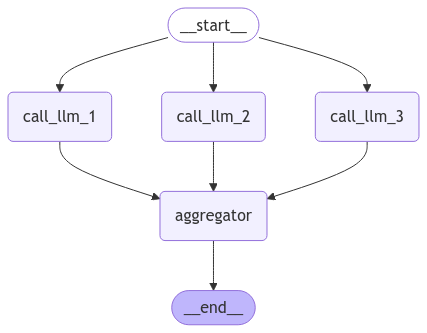

In [8]:
# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

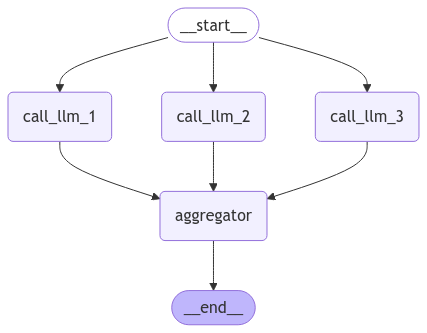

Here's a story, joke, and poem about cats!

STORY:
Once there was a magical kingdom hidden deep in an enchanted forest, where hundreds of different species of animals lived in harmony. The most intelligent creatures of all were not the lions, nor the elephants, but the cats. They lived in a majestic castle built high atop a serene hill, overseeing the rest of the kingdom. The castle was called Feline Fortress, and unlike any other place in the kingdom, it was entirely populated by cats. They wore crowns, capes, and gowns in the colors of their fur. Their leader was a majestic golden tomcat named King Joffrey.

Joffrey, with the wisdom and courage of his ancestors, ruled his cat kingdom with grace and benevolence. He ensured peace and harmony within the kingdom, settling disputes diligently, and running diplomatic missions to other animal communities. But of all his tasks as king, his favorite was time spent with his beloved queen, a graceful Himalayan cat named Queen Fluffy.

Every mor

In [9]:
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

## Routing

Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

In [4]:
from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

In [14]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )

In [15]:
# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

/home/jose/studies/langgraph-studies/.venv/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1375: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [16]:
# State
class State(TypedDict):
    input: str
    decision: str
    output: str

In [17]:
# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}

In [18]:
def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

In [19]:
# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

In [20]:
# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

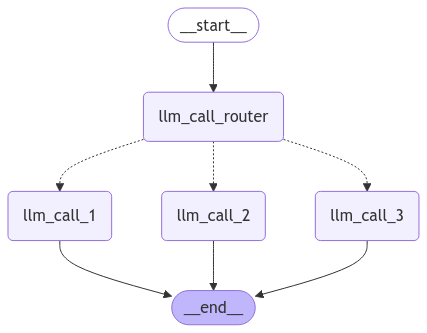

In [21]:
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [22]:
# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

Why don't cats play poker in the jungle?

Because there's too many cheetahs!


## Orchestrator - Worker

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

In [27]:
from typing import Annotated, List
import operator

In [23]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

In [24]:
# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

/home/jose/studies/langgraph-studies/.venv/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1375: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node.

In [25]:
from langgraph.constants import Send

In [28]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

In [29]:
# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [30]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


In [31]:
def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

In [32]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

In [33]:
# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

In [34]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

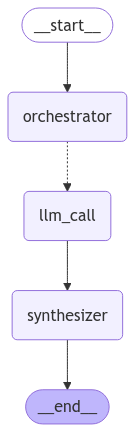

In [35]:
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [36]:
state = orchestrator_worker.invoke({"topic": "Create a report on successful landing pages"})

In [37]:
from IPython.display import Markdown
Markdown(state["final_report"])

# Introduction

This report is designed to provide an in-depth perspective on the purpose, design, and effectiveness of landing pages in the broad scope of digital marketing. Landing pages are a critical component of digital marketing strategies, acting as a storefront for a digital business, and often serving as the first point of contact between a company and its potential customers.

Landing pages serve a variety of purposes. They can be used to generate leads, sell products or services, create a positive brand image, and much more. The main goal of a landing page is to guide visitors towards your intended conversion goal, whether that be a sale, a sign-up, or a download. 

The significance of landing pages in digital marketing cannot be overstated. They serve as a crucial bridge between the traffic that your marketing initiatives generate and the conversions that you’re hoping to achieve. They are indispensable in the processes of capturing leads, nurturing them, and converting them into customers, and thus play a significant role in the sales funnel.

In order to optimize a landing page’s performance, it is critical to understand the key factors that contribute to its success. These factors, which include effective and relevant content, user-friendly design, strong call to actions (CTAs), ensuring speed and performance, and more, will be discussed in detail throughout this report. By understanding the importance of effective landing page design, businesses can greatly enhance their online marketing efforts and improve the return on their digital marketing investments.

---

## How Landing Pages Contribute to Digital Marketing Success

Landing pages are a pivotal component in the wheel of digital marketing and can massively contribute to the success of digital marketing strategies. These are specially engineered web pages where site visitors are directed, and where they are prompted to take a specific call-to-action (CTA). Hence, this dedication to a single focus makes landing pages effective tools for conversion.

Typically, landing pages harbor targeted messaging that resonates with a particular audience segment. This specificity renders them more successful in driving conversions compared to generic home pages. Consequently, landing pages enhance the ability to cater to different aspects of a company's marketing campaign, ranging from promotions, lead generation, to event registrations.

Digital marketing strategies encompass a multifold of components, among them paid advertising. In this instance, landing pages provide the final pitching stump after an ad sparks interest in a viewer. They supply further information on the ad content and guide visitors on the required action, increasing the likelihood of conversion. As a result, landing pages contribute to an appealing quality score, leading to lower advertisement costs.

Furthermore, landing pages are influential in search engine optimization (SEO). The content on landing pages can be optimized with targeted keywords, boosting the search engine ranking for these specific terms. This approach attracts more visitors, thus increasing the prospects of conversion and sales.

Yet another advantage of landing pages is in their potential to grow your email list. A substantial number of landing pages offer valuable content or services such as free ebooks or trials in exchange for email addresses. This building of email lists provides an essential pool for email marketing, crucial for nurturing leads and turning prospects into customers.

Landing pages also aid in tracking and analytics. They allow businesses to capture important data and insights into visitor behavior and campaign effectiveness. Through measuring different landing page metrics, companies can identify what works and what doesn't, applying these insights to optimize future marketing campaigns.

To conclude, landing pages contribute to the success of a digital marketing strategy by driving conversions, aiding in SEO, building email database, and boosting analytics capabilities. Their optimization to match specific audience needs enhances their effectiveness, placing them at the heart of a successful digital marketing strategy.

---

# Key Elements of Successful Landing Pages

A successful landing page plays a pivotal role in converting visitors into customers. There are several fundamental components that can optimize your landing pages for success. The following elements are critical:

## A Clear Call-To-Action

The most effective landing pages have bold and clear calls-to-action (CTAs) that tell visitors what they should do. Whether it's signing up for a newsletter, downloading an e-book, or purchasing a product, a concise CTA minimizes confusion and maximizes conversions.

## Relevant Media and Visual Aids

Visuals are important for capturing visitors' attention and improving their understanding of your product or service. This could include photos, videos, infographics, or even GIFs. Visual aids should align with the page's overall message, maintain high quality, and encourage users to engage with your CTA.

## Compelling Copy

Your copy should be engaging, clear, and direct. It's your opportunity to convey your value proposition to the visitor and convince them to take the desired action. In addition to being persuasive, the copy should also be short and scannable to accommodate visitors' typically short attention span.

## Easy Navigation

The landing page should be streamlined and uncluttered. You want to guide your visitors towards your CTA without distraction. This means avoiding extraneous links, excessive information, or anything else that might interfere with the user's journey from arrival to conversion.

## Trust Indicators

Trust indicators, such as customer testimonials, ratings, or industry certifications, can bolster your brand’s credibility and reassure visitors of your product’s value. These should be prominently displayed and visually appealing.

## Mobile Optimization

With more people browsing the web on mobile devices, it’s vital to have a mobile-optimized landing page. This means ensuring your page is readable, navigable, and visually pleasing on a smaller screen.

Putting these elements into consideration during your landing page's design and development can significantly improve its effectiveness in driving conversions and achieving your marketing goals.

---

## Case Studies of Successful Landing Pages

### 1. Shopify - E-commerce Industry
![Shopify Landing Page](https://www.shopify.com)

Shopify's landing page stands out due to its simplicity, efficiency, and practicality. It includes a clear, concise headline outlining their value proposition, "Sell everywhere, faster." Shopify uses transparent call-to-actions (CTAs) and a free trial offer to entice visitors. The page is easy to navigate, navigating users through the various available features. 

Key Success Strategies: Simplicity, clear value proposition, transparent CTAs.

### 2. Airbnb - Travel and Accommodation Industry
![Airbnb Landing Page](https://www.airbnb.com)

Airbnb's landing page offers an excellent example of personalized user engagement. Upon arriving on the page, users see a personalized greeting based on their location and contemporary booking suggestions. High-quality images and simple, enticing copy promise a desirable and unique travel experience. The search bar is primary and encourages immediate engagement from visitors.

Key Success Strategies: Personalized user experience, high-quality images, simple and engaging copy.

### 3. Slack - Technology Industry
![Slack Landing Page](https://slack.com)

Slack's landing page expertly conveys the tool's purpose and value. It showcases customer testimonials and brand logos for social proof, and the page communicates its value proposition – "A better way to communicate" through a compact video. Also, Slack keeps visitors engaged with a scrolling showcase of its features.

Key Success Strategies: Strong value proposition, customer testimonials for social proof, dynamic content.

### 4. Square - FinTech Industry
![Square Landing Page](https://squareup.com)

Square's landing page features clean design and colorful visuals that lead the visitor's eye to their compelling CTA - "Get Started." The easy-to-comprehend headline, "Start selling today," entices and urges visitors to act. Furthermore, the straightforward and brief explanation of their product with a CTA for each product line effectively maintains visitor engagement.

Key Success Strategies: Eye-catching design, compelling CTAs at strategic points, concise product explanation.
  
### 5. HubSpot - Marketing Software Industry
![HubSpot Landing Page](https://www.hubspot.com)

HubSpot's landing page utilizes an enticing headline - "Stop interrupting. Start attracting." - that immediately resonates with marketers. It features clear and concise information on their offerings, with simple illustrations aiding comprehension. HubSpot also includes success stories with impressive metrics for social proof. 

Key Success Strategies: Resonant messaging, clear informational structuring, use of social proof.

In conclusion, these successful landing pages primarily focus on clear value propositions, user-friendly designs, engaging copy, and effective use of CTAs. Social proof, in the form of testimonials or customer success stories, also greatly contributes to their effectiveness.

---

### Common Mistakes in Landing Page Design and How to Avoid Them

Website landing page design is critical considering that it is the first impression a visitor gets upon visiting a site. However, a wrong design can lead to loss of conversions, leads, and ultimately, revenue. So, understanding common mistakes designers make in creating landing pages and knowing how to avoid them can significantly improve the user experience, thus increasing the conversion rate.

**1. Failure to Clearly State What the Business Does**
 An unclear headline or business description can confuse visitors and lose the main message in the process. Always use a clear, concise headline and subheadings that quickly explain what the business offers.

**2. Too Much Clutter**
A simplistic, minimalistic design often works best. With too many elements or information, visitors can become overwhelmed and leave the page. Limit the amount of text and use whitespace effectively to guide the visitor's focus towards your call-to-action button.

**3. Non-mobile Friendly Design**
With the increasing number of mobile users, having a mobile-optimized landing page is crucial. If your page design isn't friendly to mobile users, you're undoubtedly losing leads. Always ensure your landing page design is responsive and compatible with a variety of screen sizes.

**4. Poor Call-to-Action (CTA) Placement**
Easily locating the CTA inspires visitors to engage more with your page. However, a hidden or misplaced CTA often results in loss of conversions. Ensure your CTA is bold, highly visible, and placed logically in line with other content on your page.

**5. Long Loading Times**
Website visitors aren’t patient and will quickly leave if your page takes too long to load. Hence, optimize your landing page contents to improve page load time — compress images, minimize the use of videos, or use lighter elements to speed up the site.

**6. Lack of Testing and analyzing**
Designers often launch a landing page without thorough testing, leading to poor user experience and other technical issues. Regular A/B testing, page analysis (with tools like Google Analytics), and adjusting the design accordingly is essential for a high-performing landing page.

By avoiding these common mistakes, you can create an engaging and high-performing landing page that successfully converts visitors into customers.

---

# Future Trends in Landing Page Design

As the digital marketing landscape continues to evolve, so do the trends in landing page design. Web designers and digital marketers must keep pace with these changes and ensure that their designs are in line with the latest trends. Below are some future trends that will shape the landscape of landing page design.

## 1. Mobile-First Design

With the majority of internet users accessing the web through mobile devices, mobile-first design is no longer an option but a necessity. Landing pages will be designed with mobile users in mind, with responsive design and faster load times.

## 2. Minimalistic Approach

As the saying goes, "less is more." With the increasing number of information bombarding internet users every day, a clean, uncluttered design will likely trend in the future. This minimalist approach makes it easier for users to focus on the main call-to-action on the page.

## 3. AI and Machine Learning

Artificial Intelligence (AI) and Machine Learning (ML) technologies have already started disrupting many fields, and landing page design is not an exception. AI and ML can be used to personalize websites and landing pages based on user behavior, preferences, and needs, enhancing the user experience.

## 4. Video Content

Moving forward, we can expect to see more video content on landing pages. Videos are engaging and can deliver a lot of information in a short time, making them perfect for showcasing products or services on landing pages.

## 5. Micro-Interactions

Micro-interactions, though small, can drastically enhance the user experience. They provide feedback, guide tasks, and make a landing page more enjoyable to interact with. Expect to see more of these detailed touches in future landing page designs.

## 6. Augmented Reality (AR)

With the growth of AR technologies, there are vast possibilities for its application in landing page design. AR can offer a unique and immersive user experience, which can impress visitors and encourage them to take action.

Stay ahead of the curve by integrating these future trends into your landing page designs. By adapting to these changes, brands can provide superior user experiences, improve conversions, and maximize their digital marketing investments.

---

## Conclusion 

Our analysis has shed light on numerous crucial factors that contribute to the success of landing pages. It has provided us with an understanding of the principles that govern the online consumer's behavior as well as helped in observing practices that can help boost engagement.

### Key Findings 

Our most crucial findings are as follows:

- **Simplicity and Clarity**: Users typically prefer landing pages that are easy to understand and help them swiftly locate the information they need.
- **Engaging Content**: Content that ties directly into the user's interest or needs can significantly increase engagement levels and eventually the conversion rates.
- **Effective CTAs**: Call-to-actions are a significant determinant for conversion rates. Optimally placed, attractive, and succinct CTAs drive user actions more effectively.
- **Loading Speeds**: Slow-loading landing pages can deter users and cause a significant loss in potential conversions.
- **Mobile Optimization**: Given the proliferation of mobile users, landing pages must now be optimized for mobile viewing.

### Recommendations 

Based on our findings, we recommend the following practices for creating successful landing pages:

1. **Maintain simplicity**: Keep the design straightforward and information clear to ensure users can easily understand the intent of the landing page.
2. **Improve Content Relevance**: Create compelling content that speaks directly to users' interests and provides clear solutions to their problems.
3. **Effective CTAs**: Use actionable and immediate language for CTAs and place them strategically across the landing page.
4. **Boost Load Times**: Work on improving the landing page's loading speed to offer users a seamless experience.
5. **Optimize for Mobile**: Confirm that the landing page is mobile-friendly to reach wider audiences effectively.

Our analysis's insights help in crafting landing pages that resonate with users' expectations, thereby boosting engagements and, subsequently, conversions. Businesses adopting the aforementioned best practices can vastly improve their chances of online success.


---

# Appendices

## Appendix A: Supporting Materials
This appendix consists of the supplementary documents and data that were gathered during the course of this report. These include original survey questions, interview transcripts, and field notes from observations.

## Appendix B: Statistics
This appendix includes all the raw data and statistical analyses. All percentages, mean values, and correlations mentioned in the report are derived from these data sets. They consist of survey results, both qualitative and quantitative data, and other statistical calculations used throughout the report.

## Appendix C: References
This appendix incorporates all the references mentioned in the report. It lists the complete citations for all technical papers, reports, articles, books, and other resources that have been cited. All references are listed in APA format for consistency and ease of understanding. This comprehensive list serves as a resource for readers who wish to explore the topics presented in the report in greater depth. 

The appendices are intended to provide clearer understanding, validation, and transparency of the data that were collected, analysed, and interpreted in this report. Hence, they are crucial for the completeness and reliability of the report.

## Evaluator-optimizer

In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

In [2]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [5]:
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

In [7]:
llm = ChatOpenAI(model="gpt-4")

In [8]:
evaluator = llm.with_structured_output(Feedback)

/home/jose/studies/langgraph-studies/.venv/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1375: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [9]:
# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

In [10]:
def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

In [11]:
# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


In [12]:
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

In [13]:
optimizer_workflow = optimizer_builder.compile()

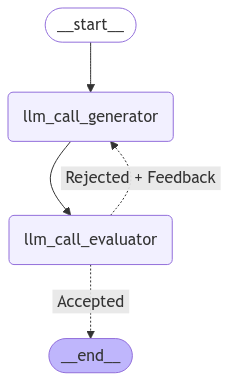

In [14]:
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [15]:
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

Why don't cats like online shopping?

They prefer a cat-alogue.


## Agent

Agents can handle sophisticated tasks, but their implementation is often straightforward. They are typically just LLMs using tools based on environmental feedback in a loop. It is therefore crucial to design toolsets and their documentation clearly and thoughtfully.

When to use agents: Agents can be used for open-ended problems where it’s difficult or impossible to predict the required number of steps, and where you can’t hardcode a fixed path. The LLM will potentially operate for many turns, and you must have some level of trust in its decision-making. Agents' autonomy makes them ideal for scaling tasks in trusted environments.

In [18]:
llm = ChatOpenAI(model="gpt-4")

In [19]:
from langchain_core.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [20]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }

In [21]:
def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [22]:
# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user)
    return END

In [23]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # Name returned by should_continue : Name of next node to visit
        "Action": "environment",
        END: END,
    },
)

In [24]:
agent_builder.add_edge("environment", "llm_call")

# Compile the agent
agent = agent_builder.compile()